#### Actividad 1 segundo parcial

## Feed Forward Network con PyTorch


In [101]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
from tqdm import tqdm

In [102]:
#Este código me ayuda a leer los datos de MNIST en el formato adecuado para que pytorch pueda usarlos
#En este caso 2051 corresponde a las imágenes y 2049 corresponde a las etiquetas


def read_idx_images(path):
  
    with open(path, "rb") as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        
        if magic != 2051:
            raise ValueError(f"Magic number inesperado: {magic}")
        
        data = np.frombuffer(f.read(), dtype=np.uint8)
    
    return data.reshape(num, rows, cols)


def read_idx_labels(path):
   
    with open(path, "rb") as f:

        magic, num = struct.unpack(">II", f.read(8))
        
        if magic != 2049:
            raise ValueError(f"Magic number inesperado: {magic}")
        
        data = np.frombuffer(f.read(), dtype=np.uint8)
    
    return data


def _find_mnist_file(data_dir, *candidates):
    for name in candidates:
        path = os.path.join(data_dir, name)
        if os.path.isfile(path):
            return path
    raise FileNotFoundError(
        f"No se encontró MNIST en {os.path.abspath(data_dir)}. "
        f"Probados: {', '.join(candidates)}"
    )


def load_mnist_dataset_idx(data_dir):

    data_dir = os.path.normpath(data_dir)
    train_images = _find_mnist_file(
        data_dir, "train-images.idx3-ubyte", "train-images-idx3-ubyte"
    )
    train_labels = _find_mnist_file(
        data_dir, "train-labels.idx1-ubyte", "train-labels-idx1-ubyte"
    )
    test_images = _find_mnist_file(
        data_dir, "t10k-images.idx3-ubyte", "t10k-images-idx3-ubyte"
    )
    test_labels = _find_mnist_file(
        data_dir, "t10k-labels.idx1-ubyte", "t10k-labels-idx1-ubyte"
    )

    x_trainval = read_idx_images(train_images)
    y_trainval = read_idx_labels(train_labels)

    x_train = x_trainval[:50000]
    y_train = y_trainval[:50000]
    x_val = x_trainval[50000:]
    y_val = y_trainval[50000:]

    x_test = read_idx_images(test_images)
    y_test = read_idx_labels(test_labels)

    return x_train, y_train, x_val, y_val, x_test, y_test

In [103]:


class MNISTDataset(Dataset):
    """
    Dataset personalizado para MNIST que carga imágenes en formato IDX
    """
    def __init__(self, images_path, labels_path, normalize=True):
        """
        Args:
            images_path: ruta al archivo de imágenes IDX
            labels_path: ruta al archivo de etiquetas IDX
            normalize: si True, normaliza las imágenes dividiendo por 255
        """
        self.images = read_idx_images(images_path)
        self.labels = read_idx_labels(labels_path)
        self.normalize = normalize
        
        if len(self.images) != len(self.labels):
            raise ValueError("Número de imágenes y etiquetas no coinciden")
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):

        img = torch.from_numpy(self.images[idx]).unsqueeze(0).float()  
        
        if self.normalize:
            img = img / 255.0
        

        label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        
        return img, label

In [104]:

DATA_DIR = r"..\..\data"

train_dataset = MNISTDataset(
    images_path=os.path.join(DATA_DIR, "train-images.idx3-ubyte"),
    labels_path=os.path.join(DATA_DIR, "train-labels.idx1-ubyte"),
    normalize=True
)

test_dataset = MNISTDataset(
    images_path=os.path.join(DATA_DIR, "t10k-images.idx3-ubyte"),
    labels_path=os.path.join(DATA_DIR, "t10k-labels.idx1-ubyte"),
    normalize=True
)

print(f"Tamaño del dataset de train: {len(train_dataset)}")
print(f"Tamaño del dataset de test: {len(test_dataset)}")

Tamaño del dataset de train: 60000
Tamaño del dataset de test: 10000


In [105]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.reshape((28,28)), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()



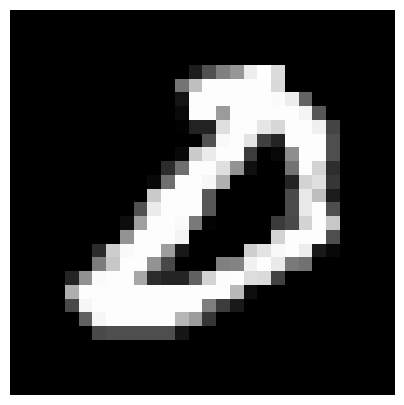

'Label: 0'

In [106]:
random_idx = np.random.randint(0, x_train.shape[0])
plot_number(x_train[random_idx])
display(f"Label: {y_train[random_idx].squeeze()}")

In [107]:
torch.manual_seed(42)
np.random.seed(42)


train_size = 50000
val_size = 10000

train_subset, val_subset = random_split(
    train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Conjunto de Train: {len(train_subset)}")
print(f"Conjunto de Validacion: {len(val_subset)} ")
print(f"Conjunto de Test: {len(test_dataset)} ")
print(f"Total: {len(train_subset) + len(val_subset) + len(test_dataset)} ")

Conjunto de Train: 50000
Conjunto de Validacion: 10000 
Conjunto de Test: 10000 
Total: 70000 


In [108]:

def build_mlp(hidden_sizes):
  
    layers = []
    in_features = 28 * 28  
    
    for hidden_size in hidden_sizes:
        layers.append(nn.Linear(in_features, hidden_size))
        layers.append(nn.ReLU())
        in_features = hidden_size
    
    layers.append(nn.Linear(in_features, 10))
    
    return nn.Sequential(*layers)


test_model = build_mlp([256, 128])
print("Ejemplo de arquitectura:")
print(test_model)

Ejemplo de arquitectura:
Sequential(
  (0): Linear(in_features=784, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=128, bias=True)
  (3): ReLU()
  (4): Linear(in_features=128, out_features=10, bias=True)
)


In [109]:
def evaluate_model(model, dataloader, criterion, device="cpu"):
   
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    
    with torch.no_grad():
        for x, y in dataloader:
            x = x.to(device)
            y = y.to(device)
            
            logits = model(x.view(x.size(0), -1))  
            loss = criterion(logits, y)
            
            batch_size = y.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += batch_size
    
    avg_loss = total_loss / total_examples
    avg_accuracy = total_correct / total_examples
    
    return avg_loss, avg_accuracy


def train_one_experiment(config, train_subset, val_subset, test_dataset, device="cpu"):

    train_loader = DataLoader(
        train_subset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0
    )
    
    val_loader = DataLoader(
        val_subset,
        batch_size=256,
        shuffle=False,
        num_workers=0
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=256,
        shuffle=False,
        num_workers=0
    )
    



    model = build_mlp(config["hidden_sizes"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    optimizer_name = config["optimizer"].lower()
    if optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    elif optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=config["lr"], momentum=0.9)
    elif optimizer_name == "rmsprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=config["lr"])
    else:
        raise ValueError(f"Optimizador no soportado: {config['optimizer']}")

    print(f"Optimizador seleccionado para {config['name']}: {optimizer_name.upper()} (lr={config['lr']})")
    
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    best_val_acc = 0.0
    best_val_epoch = 0
    
    print(f"\nEntrenando {config['name']}...")
    for epoch in range(1, config["epochs"] + 1):


        model.train()
        epoch_loss = 0.0
        epoch_correct = 0
        epoch_examples = 0
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{config['epochs']}", leave=False)
        
        for x, y in progress_bar:
            x = x.to(device)
            y = y.to(device)
            
            logits = model(x.view(x.size(0), -1))  
            loss = criterion(logits, y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            batch_size = y.size(0)
            epoch_loss += loss.item() * batch_size
            epoch_correct += (logits.argmax(dim=1) == y).sum().item()
            epoch_examples += batch_size
        
        train_loss = epoch_loss / epoch_examples
        train_acc = epoch_correct / epoch_examples
        
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device=device)
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_epoch = epoch
        
        print(
            f"[Epoch {epoch:2d}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )
    
    model.eval()
    test_loss, test_acc = evaluate_model(model, test_loader, criterion, device=device)
    
    return {
        "config": config,
        "model": model,
        "history": history,
        "best_val_acc": best_val_acc,
        "best_val_epoch": best_val_epoch,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

In [110]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")

experiments = [
    {
        "name": "Exp1_Adam_Shallow",
        "hidden_sizes": [256, 128],      
        "optimizer": "adam",
        "batch_size": 64,
        "epochs": 10,
        "lr": 1e-3
    },
    {
        "name": "Exp2_SGD_Deep",
        "hidden_sizes": [512, 256, 128, 64],  
        "optimizer": "sgd",
        "batch_size": 128,
        "epochs": 15,
        "lr": 1e-2
    },
    {
        "name": "Exp3_RMSprop_MediumBatch",
        "hidden_sizes": [256, 128, 64],   
        "optimizer": "rmsprop",
        "batch_size": 256,
        "epochs": 12,
        "lr": 5e-4
    }
]

print("Configuraciones de experimentos:")
for i, exp in enumerate(experiments, 1):
    print(f"\n{i}. {exp['name']}")
    print(f"   Arquitectura: {exp['hidden_sizes']}")
    print(f"   Optimizador: {exp['optimizer']} (lr={exp['lr']})")
    print(f"    Batch size: {exp['batch_size']}, Epocas: {exp['epochs']}")

Usando dispositivo: cpu
Configuraciones de experimentos:

1. Exp1_Adam_Shallow
   Arquitectura: [256, 128]
   Optimizador: adam (lr=0.001)
    Batch size: 64, Epocas: 10

2. Exp2_SGD_Deep
   Arquitectura: [512, 256, 128, 64]
   Optimizador: sgd (lr=0.01)
    Batch size: 128, Epocas: 15

3. Exp3_RMSprop_MediumBatch
   Arquitectura: [256, 128, 64]
   Optimizador: rmsprop (lr=0.0005)
    Batch size: 256, Epocas: 12


In [111]:
results = []

for i, config in enumerate(experiments, 1):
    print(f"Experimento {i}/3: {config['name']}")
    
    result = train_one_experiment(
        config,
        train_subset,
        val_subset,
        test_dataset,
        device=device
    )
    results.append(result)

print("Entrenamiento completado para los experimentos")


Experimento 1/3: Exp1_Adam_Shallow
Optimizador seleccionado para Exp1_Adam_Shallow: ADAM (lr=0.001)

Entrenando Exp1_Adam_Shallow...


[Epoch  1] Train Loss: 0.3061 | Train Acc: 0.9122 | Val Loss: 0.1650 | Val Acc: 0.9508


[Epoch  2] Train Loss: 0.1187 | Train Acc: 0.9643 | Val Loss: 0.1144 | Val Acc: 0.9648


[Epoch  3] Train Loss: 0.0793 | Train Acc: 0.9754 | Val Loss: 0.0892 | Val Acc: 0.9729


[Epoch  4] Train Loss: 0.0555 | Train Acc: 0.9826 | Val Loss: 0.0927 | Val Acc: 0.9728


...

[Epoch  8] Train Loss: 0.0594 | Train Acc: 0.9814 | Val Loss: 0.1121 | Val Acc: 0.9653


[Epoch  9] Train Loss: 0.0481 | Train Acc: 0.9856 | Val Loss: 0.0977 | Val Acc: 0.9708


[Epoch 10] Train Loss: 0.0404 | Train Acc: 0.9881 | Val Loss: 0.0923 | Val Acc: 0.9725


[Epoch 11] Train Loss: 0.0334 | Train Acc: 0.9897 | Val Loss: 0.1297 | Val Acc: 0.9643


[Epoch 12] Train Loss: 0.0288 | Train Acc: 0.9915 | Val Loss: 0.1020 | Val Acc: 0.9717
Entrenamiento completado para los experimentos


In [112]:
print("Resumen de resultados")

sorted_results = sorted(results, key=lambda x: x["best_val_acc"], reverse=True)

for rank, result in enumerate(sorted_results, 1):
    config = result["config"]
    print(f"\n{rank}. {config['name']}")
    print(f"   Arquitectura: {config['hidden_sizes']}")
    print(f"   Optimizador: {config['optimizer']} | Batch size: {config['batch_size']} | Épocas: {config['epochs']}")
    print(f"   Learning rate: {config['lr']}")
    print(f"   Mejor Val Accuracy: {result['best_val_acc']:.4f} (Época {result['best_val_epoch']})")
    print(f"   Test Accuracy: {result['test_acc']:.4f}")
    print(f"   Test Loss: {result['test_loss']:.4f}")

best_result = sorted_results[0]
print(f"MEJOR MODELO: {best_result['config']['name']}")
print(f"Test Accuracy: {best_result['test_acc']:.4f}")


Resumen de resultados

1. Exp1_Adam_Shallow
   Arquitectura: [256, 128]
   Optimizador: adam | Batch size: 64 | Épocas: 10
   Learning rate: 0.001
   Mejor Val Accuracy: 0.9759 (Época 8)
   Test Accuracy: 0.9791
   Test Loss: 0.0877

2. Exp2_SGD_Deep
   Arquitectura: [512, 256, 128, 64]
   Optimizador: sgd | Batch size: 128 | Épocas: 15
   Learning rate: 0.01
   Mejor Val Accuracy: 0.9743 (Época 14)
   Test Accuracy: 0.9774
   Test Loss: 0.0943

3. Exp3_RMSprop_MediumBatch
   Arquitectura: [256, 128, 64]
   Optimizador: rmsprop | Batch size: 256 | Épocas: 12
   Learning rate: 0.0005
   Mejor Val Accuracy: 0.9725 (Época 10)
   Test Accuracy: 0.9746
   Test Loss: 0.0883
MEJOR MODELO: Exp1_Adam_Shallow
Test Accuracy: 0.9791


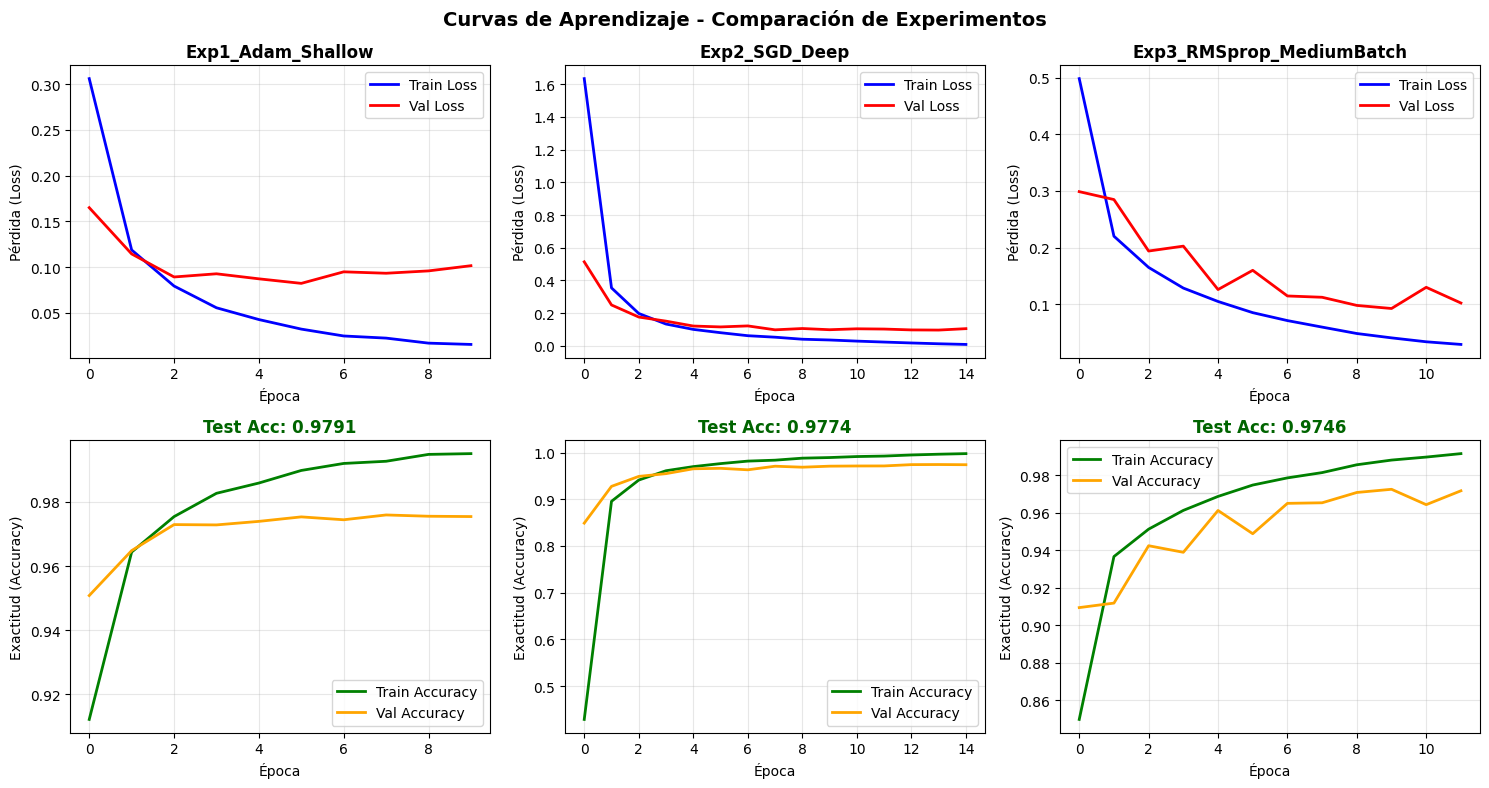

In [113]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Curvas de Aprendizaje - Comparación de Experimentos", fontsize=14, fontweight='bold')

for idx, result in enumerate(results):
    config = result["config"]
    history = result["history"]
    
    axes[0, idx].plot(history["train_loss"], label="Train Loss", linewidth=2, color='blue')
    axes[0, idx].plot(history["val_loss"], label="Val Loss", linewidth=2, color='red')
    axes[0, idx].set_title(config['name'], fontweight='bold')
    axes[0, idx].set_xlabel("Época")
    axes[0, idx].set_ylabel("Pérdida (Loss)")
    axes[0, idx].legend()
    axes[0, idx].grid(True, alpha=0.3)
    
    axes[1, idx].plot(history["train_acc"], label="Train Accuracy", linewidth=2, color='green')
    axes[1, idx].plot(history["val_acc"], label="Val Accuracy", linewidth=2, color='orange')
    axes[1, idx].set_title(f"Test Acc: {result['test_acc']:.4f}", fontweight='bold', color='darkgreen')
    axes[1, idx].set_xlabel("Época")
    axes[1, idx].set_ylabel("Exactitud (Accuracy)")
    axes[1, idx].legend()
    axes[1, idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

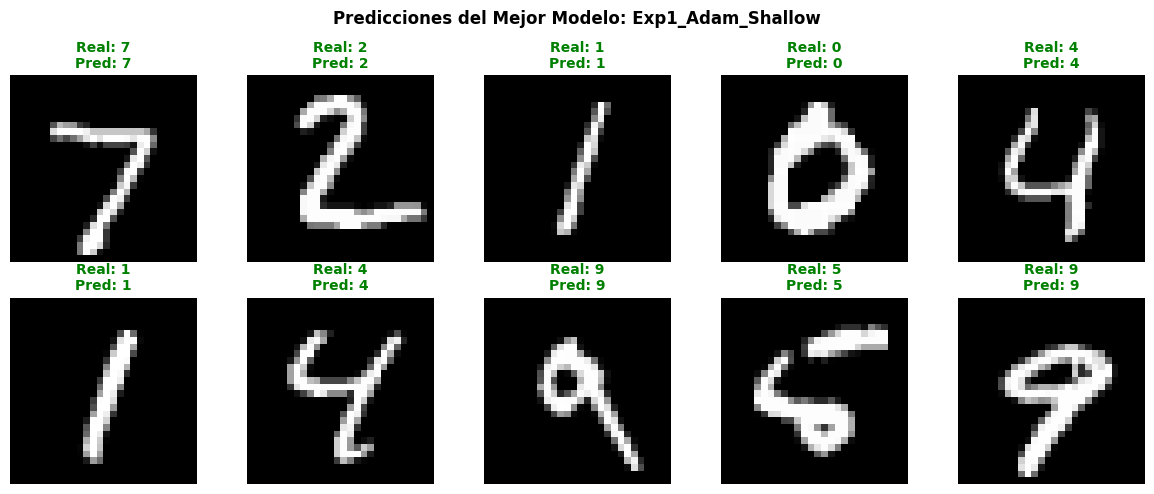

In [114]:
best_model = best_result["model"]
best_model.eval()

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)
x_sample, y_sample = next(iter(test_loader))

with torch.no_grad():
    logits = best_model(x_sample[:10].to(device).view(10, -1))
    predictions = logits.argmax(dim=1).cpu().numpy()
    true_labels = y_sample[:10].numpy()

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle(f"Predicciones del Mejor Modelo: {best_result['config']['name']}", 
             fontsize=12, fontweight='bold')

for i in range(10):
    ax = axes[i // 5, i % 5]
    img = x_sample[i].squeeze().numpy()
    ax.imshow(img, cmap='gray')
    
    color = 'green' if predictions[i] == true_labels[i] else 'red'
    title = f"Real: {true_labels[i]}\nPred: {predictions[i]}"
    ax.set_title(title, fontweight='bold', color=color, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

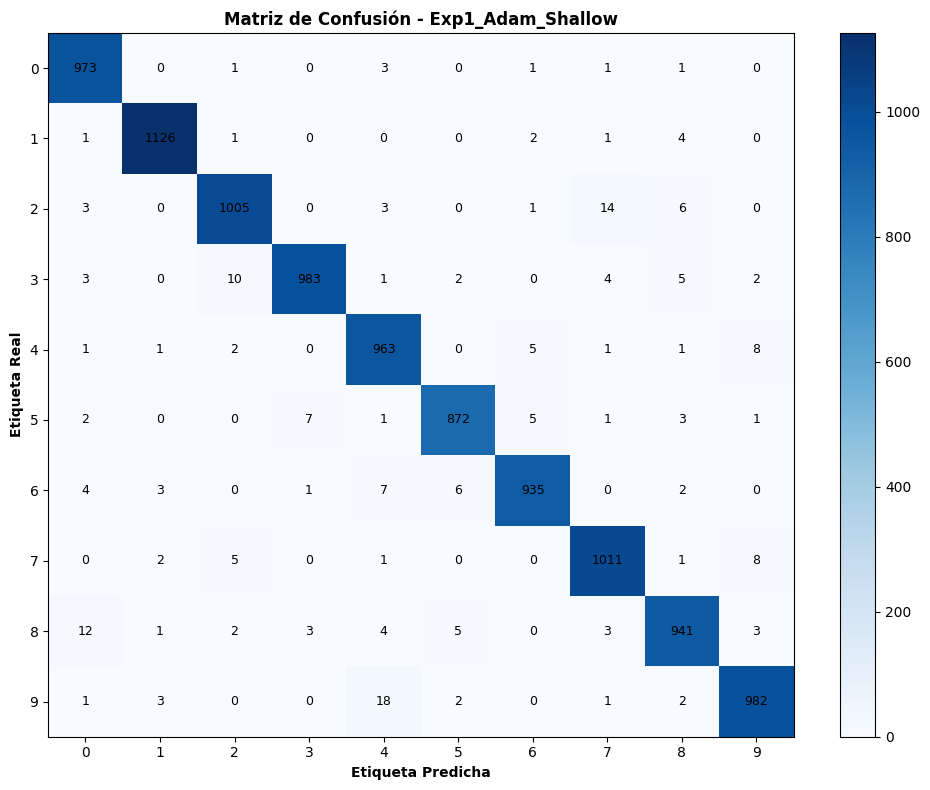


Accuracy por clase:
Clase 0: 0.9929 (973/980)
Clase 1: 0.9921 (1126/1135)
Clase 2: 0.9738 (1005/1032)
Clase 3: 0.9733 (983/1010)
Clase 4: 0.9807 (963/982)
Clase 5: 0.9776 (872/892)
Clase 6: 0.9760 (935/958)
Clase 7: 0.9835 (1011/1028)
Clase 8: 0.9661 (941/974)
Clase 9: 0.9732 (982/1009)


In [115]:
best_model.eval()
all_predictions = []
all_labels = []

test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = best_model(x.view(x.size(0), -1))
        predictions = logits.argmax(dim=1).cpu().numpy()
        all_predictions.extend(predictions)
        all_labels.extend(y.numpy())

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

num_classes = 10
confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(all_labels, all_predictions):
    confusion_matrix[true_label, pred_label] += 1

plt.figure(figsize=(10, 8))
im = plt.imshow(confusion_matrix, cmap='Blues', aspect='auto')

for i in range(num_classes):
    for j in range(num_classes):
        text = plt.text(j, i, confusion_matrix[i, j],
                        ha="center", va="center", color="black", fontsize=9)

plt.colorbar(im)
plt.xlabel("Etiqueta Predicha", fontweight='bold')
plt.ylabel("Etiqueta Real", fontweight='bold')
plt.title(f"Matriz de Confusión - {best_result['config']['name']}", fontweight='bold')
plt.xticks(range(num_classes))
plt.yticks(range(num_classes))
plt.tight_layout()
plt.show()

print("\nAccuracy por clase:")
for i in range(num_classes):
    if confusion_matrix[i].sum() > 0:
        class_acc = confusion_matrix[i, i] / confusion_matrix[i].sum()
        print(f"Clase {i}: {class_acc:.4f} ({confusion_matrix[i, i]}/{confusion_matrix[i].sum()})")